# Loading & Preprocessing Data 
Supported TensorFlow datasets:
- MNIST
- CIFAR-10

Other supported datasets:
- TBA

In [1]:
import sys
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

sys.path.append("..") # to access nn_lib files

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.show()
plt.rcParams.update({'font.size': 18})

%load_ext autoreload
%autoreload 2

I0000 00:00:1773936790.423034  182516 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773936790.479490  182516 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773936791.612041  182516 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
from nn_lib.data_loading.image_datasets import load_img_dataset, train_val_split, plot_imgs

# CIFAR-10

### Load raw data

In [3]:
x_train, y_train, x_test, y_test, classnames = load_img_dataset('cifar10', "none", False, verbose=True)
print()
print(f'Your training set min/max are {tf.reduce_min(x_train)}/{tf.reduce_max(x_train)} and should be 0.0/1.0')
print(f'The unique set of your train labels are {np.unique(y_train)} and should be [0 1 2 3 4 5 6 7 8 9]')
print(f'The unique set of your test labels are {np.unique(y_test)} and should be [0 1 2 3 4 5 6 7 8 9]')

/home/levi/python-code/Neural-Nets-Library/.venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")
W0000 00:00:1773936794.183023  182516 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


[DEBUG] Fetching 'cifar10' dataset using norm method 'none'. Flattening data? False
[DEBUG] x_train.shape: (50000, 32, 32, 3) | type: <class 'tensorflow.python.framework.ops.EagerTensor'>
[DEBUG]     x_train min/max: 0.00/1.00
[DEBUG] x_test.shape: (10000, 32, 32, 3) | type: <class 'tensorflow.python.framework.ops.EagerTensor'>
[DEBUG]     x_test min/max: 0.00/1.00
[DEBUG] y_train.shape: (50000,) | type: <class 'tensorflow.python.framework.ops.EagerTensor'>
[DEBUG]     y_train min/max: 0.00/9.00
[DEBUG] y_test.shape: (10000,) | type: <class 'tensorflow.python.framework.ops.EagerTensor'>
[DEBUG]     y_test min/max: 0.00/9.00

Your training set min/max are 0.0/1.0 and should be 0.0/1.0
The unique set of your train labels are [0 1 2 3 4 5 6 7 8 9] and should be [0 1 2 3 4 5 6 7 8 9]
The unique set of your test labels are [0 1 2 3 4 5 6 7 8 9] and should be [0 1 2 3 4 5 6 7 8 9]


In [4]:
!pip list | grep numpy 
!pip list | grep matplotlib
!pip list | grep tensorflow 
!pip list | grep keras 

numpy                     2.4.3
matplotlib                3.10.8
matplotlib-inline         0.2.1
tensorflow                2.21.0
keras                     3.13.2


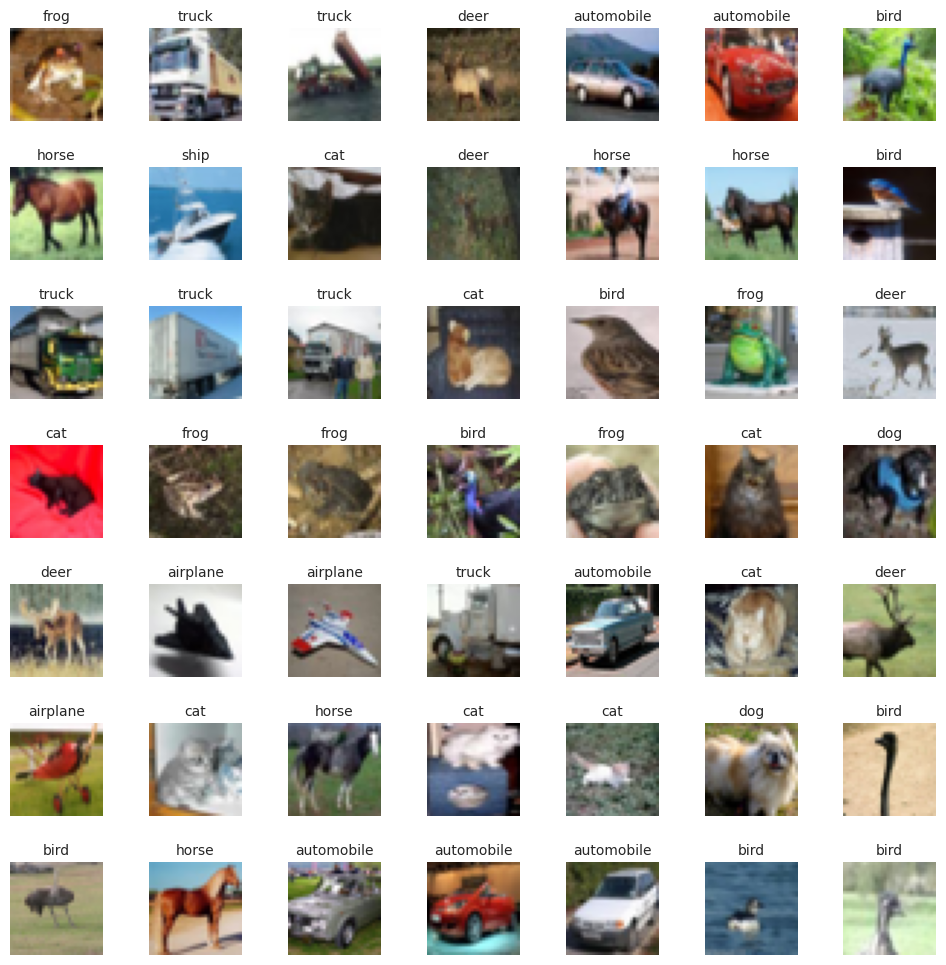

In [5]:
plot_imgs(x_train, y_train, classnames)

### Load flattened data

In [6]:
x_train, y_train, x_test, y_test, classnames = load_img_dataset('cifar10', "none", True, verbose=True)

[DEBUG] Fetching 'cifar10' dataset using norm method 'none'. Flattening data? True
[DEBUG] x_train.shape: (50000, 3072) | type: <class 'tensorflow.python.framework.ops.EagerTensor'>
[DEBUG]     x_train min/max: 0.00/1.00
[DEBUG] x_test.shape: (10000, 3072) | type: <class 'tensorflow.python.framework.ops.EagerTensor'>
[DEBUG]     x_test min/max: 0.00/1.00
[DEBUG] y_train.shape: (50000,) | type: <class 'tensorflow.python.framework.ops.EagerTensor'>
[DEBUG]     y_train min/max: 0.00/9.00
[DEBUG] y_test.shape: (10000,) | type: <class 'tensorflow.python.framework.ops.EagerTensor'>
[DEBUG]     y_test min/max: 0.00/9.00


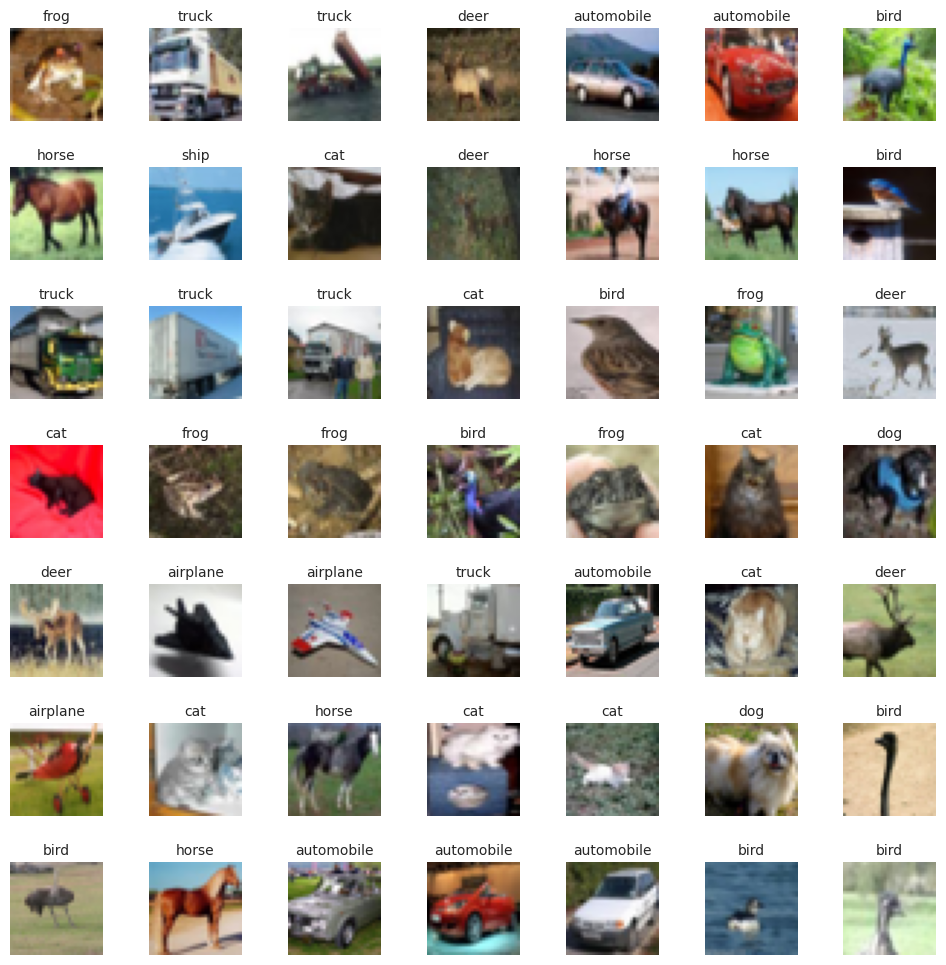

In [ ]:
# reconstruct flattened data using reshape_dims parameter & dataset original feature shape
plot_imgs(x_train, y_train, classnames, reshape_dims=[32,32,3])

### Global standardization 

In [9]:
x_train, y_train, x_test, y_test, classnames = load_img_dataset('cifar10', norm_method='global', verbose=True)
print()
print(f'The min/max of your training set is {tf.reduce_min(x_train):.4f}/{tf.reduce_max(x_train):.4f}')
print('and they should be                  -1.9892/2.1268')
print(f'The min/max of your test set is {tf.reduce_min(x_test):.4f}/{tf.reduce_max(x_test):.4f}')
print('and they should be              -1.9892/2.1268')

[DEBUG] Fetching 'cifar10' dataset using norm method 'global'. Flattening data? True
[DEBUG] x_train.shape: (50000, 3072) | type: <class 'tensorflow.python.framework.ops.EagerTensor'>
[DEBUG]     x_train min/max: -1.22/2.51
[DEBUG] x_test.shape: (10000, 3072) | type: <class 'tensorflow.python.framework.ops.EagerTensor'>
[DEBUG]     x_test min/max: -1.22/2.51
[DEBUG] y_train.shape: (50000,) | type: <class 'tensorflow.python.framework.ops.EagerTensor'>
[DEBUG]     y_train min/max: 0.00/9.00
[DEBUG] y_test.shape: (10000,) | type: <class 'tensorflow.python.framework.ops.EagerTensor'>
[DEBUG]     y_test min/max: 0.00/9.00

The min/max of your training set is -1.2222/2.5076
and they should be                  -1.9892/2.1268
The min/max of your test set is -1.2222/2.5076
and they should be              -1.9892/2.1268


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.222154..2.4674594].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1294286..2.4929378].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9255565..2.507564].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1636486..2.1256].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.222154..2.4081817].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.222154..2.3799233].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1197696..2.40

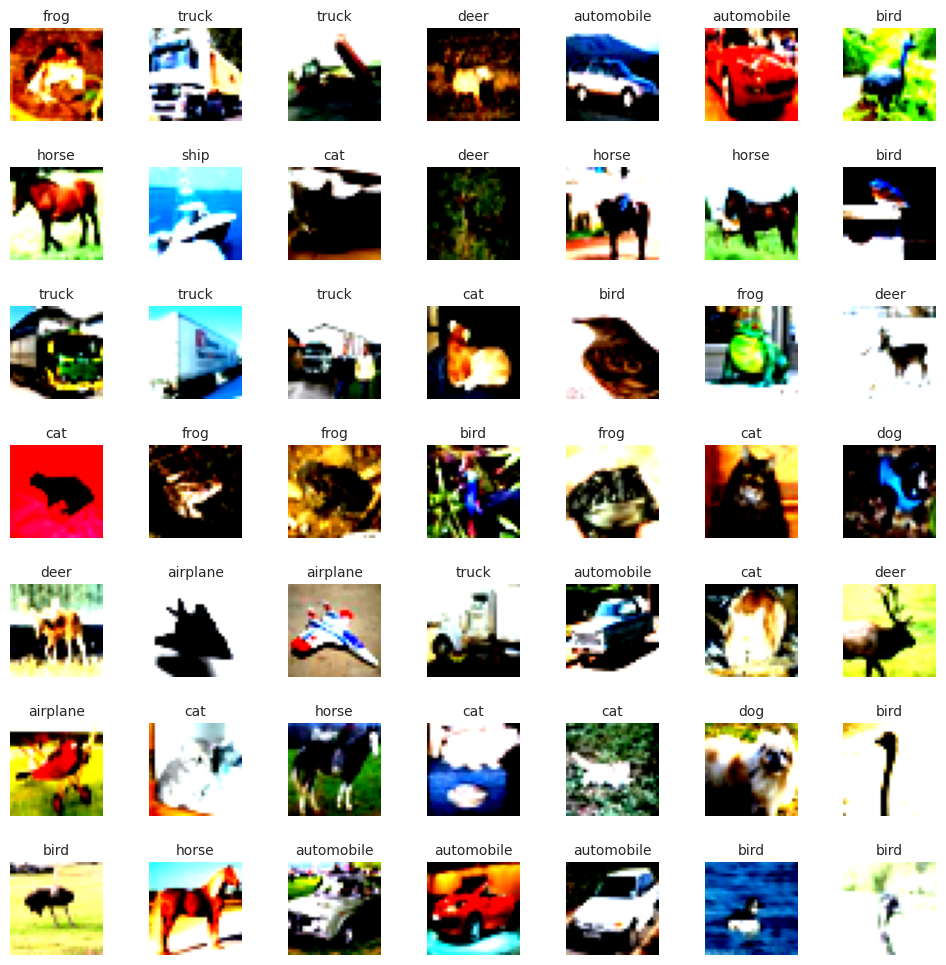

In [ ]:
plot_imgs(x_train, y_train, classnames, reshape_dims=[32,32,3])

### Centering

In [12]:
x_train, y_train, x_test, y_test, classnames = load_img_dataset('cifar10', norm_method='center', verbose=True)
print()
print(f'The min/max of your training set is {tf.reduce_min(x_train):.4f}/{tf.reduce_max(x_train):.4f}')
print('and they should be                  -0.4914/0.5535')
print(f'The min/max of your test set is {tf.reduce_min(x_test):.4f}/{tf.reduce_max(x_test):.4f}')
print('and they should be              -0.4914/0.5535')

/home/levi/python-code/Neural-Nets-Library/.venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


[DEBUG] Fetching 'cifar10' dataset using norm method 'center'. Flattening data? True
[DEBUG] x_train.shape: (50000, 3072) | type: <class 'tensorflow.python.framework.ops.EagerTensor'>
[DEBUG]     x_train min/max: -0.33/0.67
[DEBUG] x_test.shape: (10000, 3072) | type: <class 'tensorflow.python.framework.ops.EagerTensor'>
[DEBUG]     x_test min/max: -0.33/0.67
[DEBUG] y_train.shape: (50000,) | type: <class 'tensorflow.python.framework.ops.EagerTensor'>
[DEBUG]     y_train min/max: 0.00/9.00
[DEBUG] y_test.shape: (10000,) | type: <class 'tensorflow.python.framework.ops.EagerTensor'>
[DEBUG]     y_test min/max: 0.00/9.00

The min/max of your training set is -0.3277/0.6723
and they should be                  -0.4914/0.5535
The min/max of your test set is -0.3277/0.6723
and they should be              -0.4914/0.5535


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.32768..0.67232].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.30807215..0.66839844].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.24924862..0.67232].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.31199372..0.5899671].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.32768..0.66839844].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.32768..0.6605553].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.300229..0.6

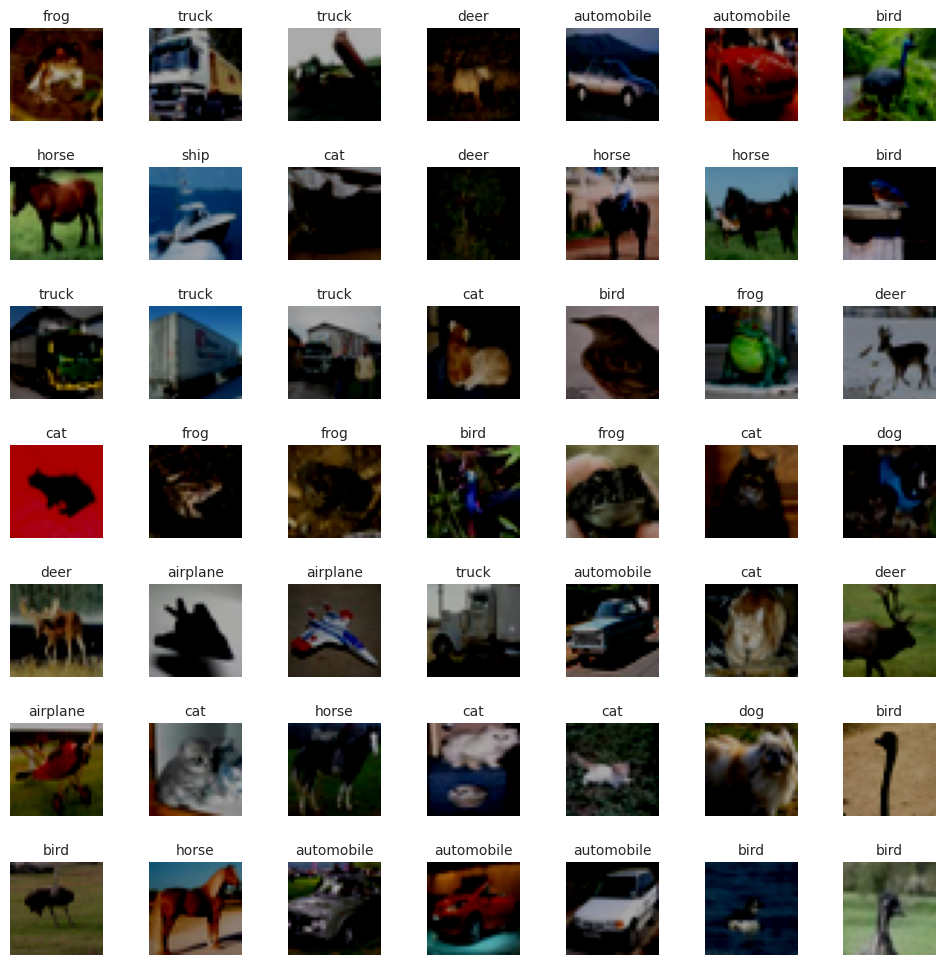

In [14]:
plot_imgs(x_train, y_train, classnames, reshape_dims=[32,32,3])

## Creating validation splits

In [20]:
x_train, y_train, x_test, y_test, classnames = load_img_dataset('cifar10', norm_method='none', flatten=False)
x_train_split, y_train_split, x_val_split, y_val_split = train_val_split(x_train, y_train, prop_val=0.25)

print('The shape of your CIFAR-10 train and test sets are:')
print(f'{x_train_split.shape=} {y_train_split.shape=}')
print(f'{x_val_split.shape=} {y_val_split.shape=}')
print(f'{x_test.shape=} {y_test.shape=}')

/home/levi/python-code/Neural-Nets-Library/.venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


The shape of your CIFAR-10 train and test sets are:
x_train_split.shape=TensorShape([37500, 32, 32, 3]) y_train_split.shape=TensorShape([37500])
x_val_split.shape=TensorShape([12500, 32, 32, 3]) y_val_split.shape=TensorShape([12500])
x_test.shape=TensorShape([10000, 32, 32, 3]) y_test.shape=TensorShape([10000])


# MNIST